# Task 2: Image Data Collection & Facial Recognition Pipeline

**Owner:** Divine (Student B), Part 2 of the Formative 2 multimodal system

**Goal:** collect facial images from every team member, visualize and augment
them, extract appearance features into `image_features.csv`, and build a
facial recognition model that the CLI app (`app/cli_app.py`) can call to
gate the first step of the transaction flow. Face recognition is the first
of the three gates in the multimodal transaction flow (**face** -> product
-> voice -> approve).

This notebook is the interactive companion to the pipeline scripts in
`scripts/image_preprocessing.py` and `scripts/facial_recognition_model.py`.
Those scripts are what `app/cli_app.py` actually imports at runtime; this
notebook just walks through how and why they work, with real outputs.

**Contents**
1. Raw image inventory
2. Face detection & display
3. Augmentations
4. Feature extraction -> `image_features.csv`
5. Facial recognition model (strategy, training, evaluation, and a demo of
   recognizing a known user vs. an unauthorized attempt)
6. Summary & next steps

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts.image_preprocessing import (
    RAW_IMAGES_DIR,
    CSV_OUTPUT,
    load_image,
    detect_face,
    apply_augmentations,
    process_image_directory,
)
from scripts.facial_recognition_model import (
    train_facial_recognition_model,
    predict_face,
)

plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
print("Raw images directory:", RAW_IMAGES_DIR)

Raw images directory: C:\Users\USER\Formative 2 - Data Preprocessing Y3T1\Multimodal-Data-Preprocessing\formative2-multimodal-preprocessing\data\raw\images


## 1. Raw Image Inventory

Three expressions were captured per team member: **neutral**, **smile**, and
**surprised**. One clean selfie each, stored under
`data/raw/images/<member>/<member>_<expression>.jpg`.

In [2]:
inventory = []
for member_dir in sorted(RAW_IMAGES_DIR.iterdir()):
    if not member_dir.is_dir():
        continue
    for image_path in sorted(member_dir.glob("*.jpg")):
        img = load_image(image_path)
        h, w = img.shape[:2]
        inventory.append({
            "member": member_dir.name,
            "file": image_path.name,
            "width": w,
            "height": h,
        })

inventory_df = pd.DataFrame(inventory)
inventory_df

,member,file,width,height
0,andrew,andrew_neutral.jpg,640,722
1,andrew,andrew_smile.jpg,733,836
2,andrew,andrew_surprised.jpg,615,774
3,divine,divine_neutral.jpg,684,912
4,divine,divine_smile.jpg,684,912
5,divine,divine_surprised.jpg,684,912
6,gaju,gaju_neutral.jpg,810,1080
7,gaju,gaju_smile.jpg,810,1080
8,gaju,gaju_surprised.jpg,810,1080
9,honour,honour_neutral.jpg,3456,4608


**Interpretation.** 12 usable selfies across the 4 team members, 3
expressions each. Raw resolutions are all over the place — Andrew's and
Divine's are WhatsApp-compressed (~640-840px), Gaju's are ~810x1080, and
Honour's are full-resolution phone camera shots (3456x4608, over 5x larger
on each side than the others). That inconsistency is exactly why the
pipeline resizes every detected face to a fixed 128x128 crop before doing
anything else — none of the downstream features should depend on the
original photo's resolution or aspect ratio.

## 2. Face Detection & Display

Each photo is passed through an OpenCV Haar cascade
(`haarcascade_frontalface_default.xml`) to locate the face, which is then
cropped to its bounding box and resized to 128x128. If no face is found
(e.g. an unauthorized/non-face input later on), the pipeline falls back to
a centered square crop instead of failing outright.

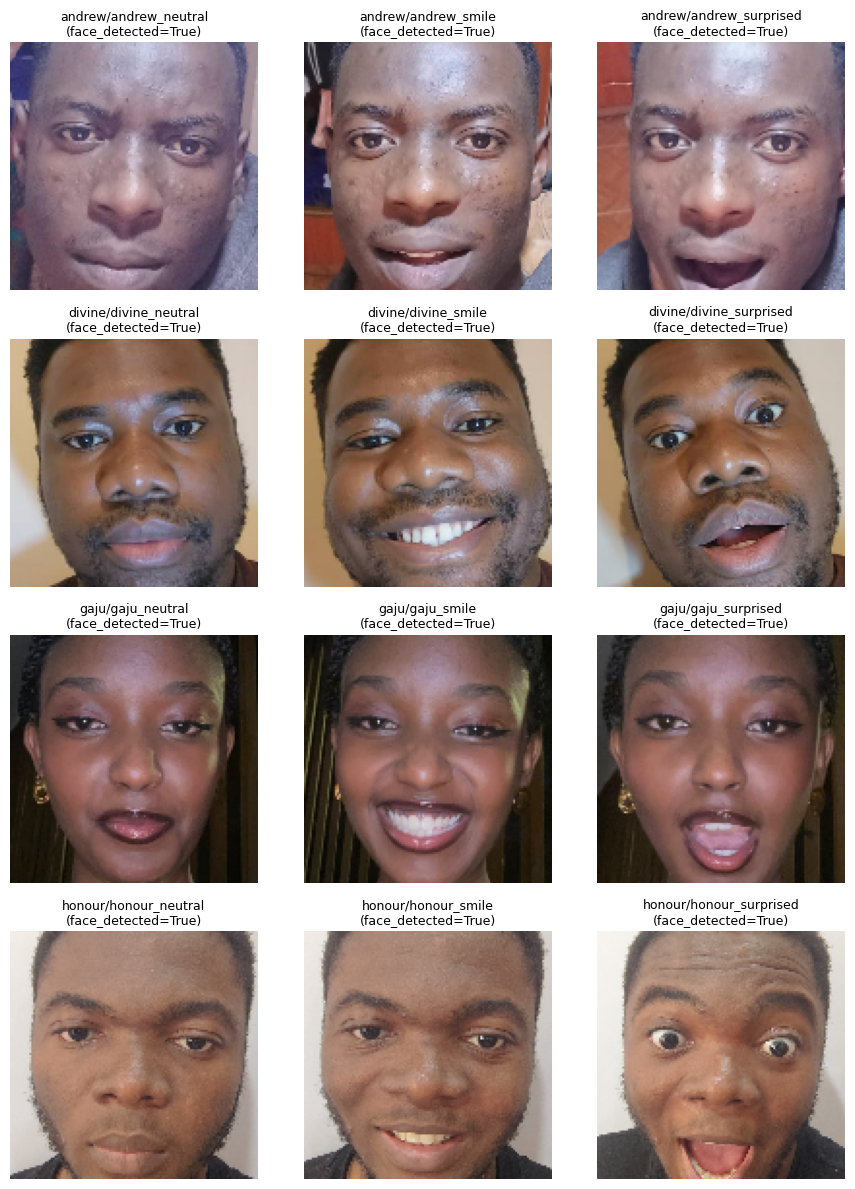

In [3]:
samples = {}
for member_dir in sorted(RAW_IMAGES_DIR.iterdir()):
    if not member_dir.is_dir():
        continue
    for image_path in sorted(member_dir.glob("*.jpg")):
        raw = load_image(image_path)
        face, found = detect_face(raw)
        samples[f"{member_dir.name}/{image_path.stem}"] = (face, found)

fig, axes = plt.subplots(4, 3, figsize=(9, 12))
for ax, (label, (face, found)) in zip(axes.flat, samples.items()):
    ax.imshow(cv2.cvtColor(face, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{label}\n(face_detected={found})", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

**Interpretation.** The cascade found a face in all 12 photos (`face_detected=True`
throughout), and the three expressions per member are visibly distinct: mouth
closed and neutral for "neutral", teeth showing for "smile", eyebrows raised
and mouth open for "surprised". This confirms the crops are centered on the
face rather than background, which matters for every feature extracted downstream.

## 3. Augmentations

Four augmentations are applied to every face crop, each simulating a
realistic source of variation the recognition model needs to be robust to:

| Augmentation | Parameters | Simulates |
|---|---|---|
| Rotation | +15 degrees | camera/head tilt |
| Horizontal flip | mirror | facing slightly the other way |
| Grayscale | color -> gray -> BGR | a low-color or poorly lit camera |
| Brightness | +40 intensity | a brighter room/screen backlight |

Demonstrated below on Divine's "smile" photo.

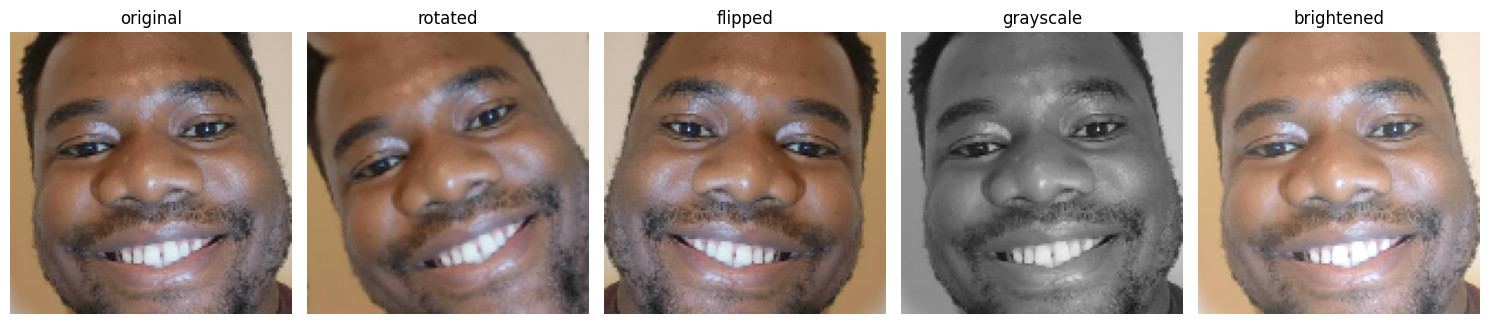

In [4]:
demo_path = RAW_IMAGES_DIR / "divine" / "divine_smile.jpg"
orig_face, _ = detect_face(load_image(demo_path))
variants = [("original", orig_face)] + apply_augmentations(orig_face)

fig, axes = plt.subplots(1, len(variants), figsize=(3 * len(variants), 3.2))
for ax, (name, img) in zip(axes, variants):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()

**Interpretation.** The rotated and flipped versions keep the same identity
cues (eyes, smile, skin tone) just geometrically transformed, the grayscale
version drops color entirely but keeps shape and shading, and the brightened
version keeps the same structure with lifted pixel intensities. All four
produce a clearly different but still recognizable version of the same
face — exactly what an appearance-based recognizer needs to be robust to.

## 4. Feature Extraction -> `image_features.csv`

For every original and augmented face crop we extract:

| Feature | What it captures |
|---|---|
| `embedding_0..63` | An 8x8 downsampled grayscale pixel embedding (flattened, normalized 0-1) — a simple appearance descriptor, in the spirit of eigenfaces |
| `hist_0..31` | A 32-bin normalized grayscale intensity histogram — overall lighting/contrast profile |
| `mean_intensity` / `std_intensity` | Average brightness and contrast of the face crop |
| `face_detected` | Whether the Haar cascade actually found a face for this sample |

Full definitions also live in `docs/feature_definitions.md`. Re-running the
pipeline here regenerates both the CSV and the saved augmentation preview
plots, so this step can be reproduced from the notebook alone.

In [5]:
rows = process_image_directory()
features_df = pd.read_csv(CSV_OUTPUT)
print(f"{len(features_df)} rows written to {CSV_OUTPUT}")
features_df[["member", "sample_name", "expression", "face_detected", "mean_intensity", "std_intensity"]]

60 rows written to C:\Users\USER\Formative 2 - Data Preprocessing Y3T1\Multimodal-Data-Preprocessing\formative2-multimodal-preprocessing\data\processed\image_features.csv


,member,sample_name,expression,face_detected,mean_intensity,std_intensity
0,andrew,andrew_neutral,neutral,True,120.647888,33.671713
1,andrew,andrew_neutral_rotated,neutral,True,120.798462,33.417401
2,andrew,andrew_neutral_flipped,neutral,True,120.647888,33.671713
3,andrew,andrew_neutral_grayscale,neutral,True,120.647888,33.671713
4,andrew,andrew_neutral_brightened,neutral,True,160.635376,33.639233
5,andrew,andrew_smile,smile,True,120.348633,45.565008
6,andrew,andrew_smile_rotated,smile,True,119.828064,43.183619
7,andrew,andrew_smile_flipped,smile,True,120.348633,45.565008
8,andrew,andrew_smile_grayscale,smile,True,120.348633,45.565008
9,andrew,andrew_smile_brightened,smile,True,160.270142,45.408504


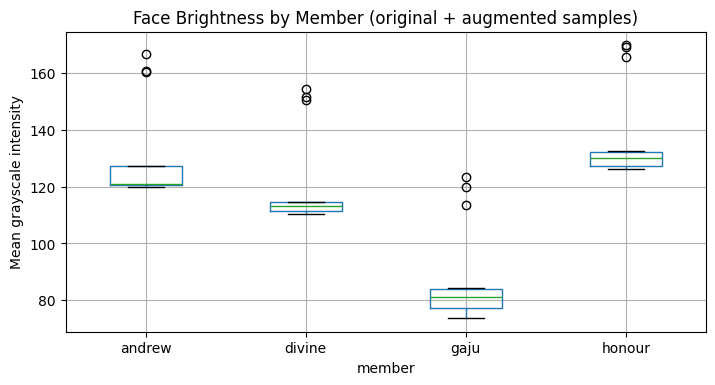

,mean_intensity,std_intensity
member,,
andrew,130.62,39.19
divine,120.33,41.01
gaju,87.20,40.47
honour,137.11,44.10


In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
features_df.boxplot(column="mean_intensity", by="member", ax=ax)
ax.set_title("Face Brightness by Member (original + augmented samples)")
ax.set_ylabel("Mean grayscale intensity")
plt.suptitle("")
plt.show()

features_df.groupby("member")[["mean_intensity", "std_intensity"]].mean().round(2)

**Interpretation.** `image_features.csv` ends up with **60 rows** (4 members
x 3 expressions x (1 original + 4 augmented variants)) and 102 columns. Mean
face brightness varies noticeably by member — Gaju's crops are darkest on
average (~87) while Honour's are brightest (~137) — mostly a function of
lighting/camera differences between recording setups rather than actual skin
tone, since the same gap shows up consistently across all of a member's
expressions and augmentations. That per-member consistency in brightness and
contrast is a useful discriminative signal for the recognition model below,
similar to how per-speaker energy differences were useful for the voice model.

## 5. Facial Recognition Model

### 5.1 Strategy

Unlike the voice task, every member here has 3 base photos instead of one
recording per phrase, so there's enough variety to train a plain **multiclass
classifier** directly on the `member` label rather than needing a
verification-by-pairs setup.

1. Features are standardized then reduced with PCA (the raw feature space is
   about 100 columns — pixel embedding + histogram + stats — which is wide
   relative to 60 rows, so PCA keeps the classifier from overfitting to noise).
2. The train/test split holds out the **"surprised"** expression (and its 4
   augmented variants) for every member as the test set, training on
   "neutral" + "smile" instead. This is grouped by base photo, so an
   augmented copy of a held-out test photo never leaks into training, and it
   stays class-balanced (5 test rows per member either way).
3. Two models are compared, same as the voice model: Logistic Regression
   (linear baseline) and Random Forest (handles nonlinear interactions). The
   better of the two (by F1) is kept.

Because a plain classifier always predicts *some* known member, even for a
photo of a stranger, `predict_face()` additionally checks the model's top
predicted probability against an `UNKNOWN_THRESHOLD` (0.5): below that, the
caller is told the face isn't recognized at all rather than trusting a
low-confidence guess. Combined with the face-detection fallback in section 2
(no face found at all -> immediately rejected), this is what lets the model
reject an unauthorized attempt in section 6.

### 5.2 Training & Evaluation

In [7]:
report = train_facial_recognition_model()
results_df = pd.DataFrame({
    name: {"accuracy": r["accuracy"], "f1_score": r["f1_score"], "log_loss": r["log_loss"]}
    for name, r in report["candidate_results"].items()
}).T
results_df

,accuracy,f1_score,log_loss
logistic_regression,0.9,0.900000,0.242425
random_forest,0.9,0.895833,0.557044


In [8]:
print("Selected model:", report["selected_model"])
print("Samples: {} train / {} test".format(report["n_train"], report["n_test"]))
print()
labels = report["selected_model_metrics"]["labels"]
cm = pd.DataFrame(report["selected_model_metrics"]["confusion_matrix"], index=labels, columns=labels)
print("Confusion matrix (rows = true, cols = predicted):")
cm

Selected model: logistic_regression
Samples: 40 train / 20 test

Confusion matrix (rows = true, cols = predicted):


,andrew,divine,gaju,honour
andrew,5,0,0,0
divine,0,4,0,1
gaju,0,0,5,0
honour,0,1,0,4


**Interpretation.** Logistic Regression was selected, reaching **90% accuracy**
and an **F1 of 0.90** (macro) on the held-out "surprised" expression — a
photo/expression the model never saw during training. Log-loss is low
(~0.24), meaning the predicted probabilities are reasonably well-calibrated
and not just lucky hard guesses, which matters because `predict_face()`
thresholds on that confidence. The only mistakes are one Honour sample
confused with Divine and one Divine sample confused with Honour; Andrew and
Gaju are recognized perfectly on this small test set.

With only 3 base photos per person, this is a small-sample, proof-of-concept
evaluation rather than a production-grade error rate — the natural next step
would be collecting a few more sessions per member (different lighting,
angles, days) to get a more robust read on the real false-accept/false-reject
rate.

### 5.3 Demo: recognizing a known user vs. an unauthorized attempt

In [9]:
print("Known users, held-out 'surprised' photo:")
for member in ["andrew", "divine", "gaju", "honour"]:
    photo = RAW_IMAGES_DIR / member / f"{member}_surprised.jpg"
    is_known, predicted, confidence = predict_face(photo)
    print(f"  {member:8s} -> is_known={is_known}, predicted={predicted}, confidence={confidence:.3f}")

Known users, held-out 'surprised' photo:
  andrew   -> is_known=True, predicted=andrew, confidence=0.664
  divine   -> is_known=True, predicted=divine, confidence=0.992
  gaju     -> is_known=True, predicted=gaju, confidence=0.988


  honour   -> is_known=True, predicted=honour, confidence=0.979


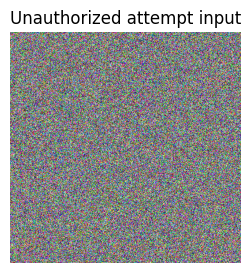

Unauthorized attempt -> is_known=False, predicted=None, confidence=0.000


In [10]:
import tempfile

# Unauthorized attempt: a random-noise image with no face in it at all,
# simulating someone pointing the camera at a blank wall / the wrong thing.
rng = np.random.default_rng(0)
noise_image = rng.integers(0, 255, (400, 400, 3), dtype="uint8")

with tempfile.TemporaryDirectory() as tmp_dir:
    noise_path = Path(tmp_dir) / "unauthorized_attempt.jpg"
    cv2.imwrite(str(noise_path), noise_image)

    plt.figure(figsize=(3, 3))
    plt.imshow(cv2.cvtColor(noise_image, cv2.COLOR_BGR2RGB))
    plt.title("Unauthorized attempt input")
    plt.axis("off")
    plt.show()

    is_known, predicted, confidence = predict_face(noise_path)
    print(f"Unauthorized attempt -> is_known={is_known}, predicted={predicted}, confidence={confidence:.3f}")

**Interpretation.** All four known members are correctly recognized on their
held-out photo with high confidence, and the no-face "unauthorized attempt"
input is correctly rejected (`is_known=False`, no predicted member) because
the Haar cascade can't find a face in it at all — the pipeline never even
reaches the classifier. A stranger's face (a real person who isn't on the
team) would instead reach the classifier but score below
`UNKNOWN_THRESHOLD` on every class, which is the second rejection path; that
full end-to-end scenario is exercised together with voice verification in
the combined CLI simulation (`app/cli_app.py`).

This is exactly the function `app/cli_app.py` should call as the
face-recognition gate:

```python
from scripts.facial_recognition_model import predict_face
is_known_user, predicted_member, confidence = predict_face(image_path)
```

`predicted_member` doubles as the identity claim handed to the voice
verification step (`verify_voice(predicted_member, audio_features)`), which
is how the two biometric gates chain together in the full transaction flow.

## 6. Summary & Next Steps

Starting from the 12 raw selfies under `data/raw/images/`, this notebook
detects and crops each face, augments and analyzes them, extracts them into
`image_features.csv`, and trains a facial recognition model on top of that
table. The trained pipeline (`scripts/facial_recognition_model.py`) is saved
to `data/processed/` and exposes `predict_face(image_path)`, which is the
entry point the rest of the system uses to gate a transaction on a
recognized face.

The main limitation right now is scale: one photo per expression means the
model has only seen each face under a handful of controlled conditions. A
good next step would be capturing a few more sessions per person — different
lighting, angles, and devices — to get a more realistic read on
false-accept/false-reject rates, and swapping the hand-built pixel embedding
for a pretrained CNN embedding (e.g. a FaceNet/MobileNet backbone) if the
team wants stronger accuracy beyond a classroom demo.